In [19]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [20]:
class Perceptron:

    def __init__(self, learning_rate=0.01, batch_size=64, max_iter=1500, random_state=42, verbose=False) -> None:

        self.lr = learning_rate
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.coefs_ = None
        self.verbose = verbose
        np.random.seed(random_state)
    

    def predict(self, X):

        m = X.shape[0]
        X = np.hstack((np.ones((m, 1)), X))
        return self.step(np.dot(X, self.coefs_))
    

    def batch_generator(self, X, y, batch_size):

        num_samples = X.shape[0]
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            yield X_shuffled[start : end], y_shuffled[start : end]
    

    def step(self, prediction):

        return np.where(prediction > 0, 1, -1)
    

    def fit(self, X, y):

        m, n = X.shape
        X = np.hstack((np.ones((m, 1)), X))

        if y.ndim == 1:

            self.coefs_ = np.random.uniform(-0.5, 0.5, size=(n + 1, ))
        
        else:
            
            self.coefs_ = np.random.uniform(-0.5, 0.5, size=(n + 1, 1))


        for e in range(self.max_iter):
            
            for x_batch, y_batch in self.batch_generator(X, y, self.batch_size):
                
                pred = np.dot(x_batch, self.coefs_)
                error = y_batch - self.step(pred)
                
                self.coefs_ += self.lr * np.dot(x_batch.T, error)

            full_pred = self.step(np.dot(X, self.coefs_))
            accuracy = (y == full_pred).mean()

            if self.verbose:
                print(f"epoch {e}/{self.max_iter} -- accuracy {accuracy:.4f}")

            if accuracy == 1.0:
                break

epoch 0/100 -- accuracy 0.9450
epoch 1/100 -- accuracy 0.9450
epoch 2/100 -- accuracy 0.9200
epoch 3/100 -- accuracy 0.9300
epoch 4/100 -- accuracy 0.8500
epoch 5/100 -- accuracy 0.9350
epoch 6/100 -- accuracy 0.9250
epoch 7/100 -- accuracy 0.9050
epoch 8/100 -- accuracy 0.9150
epoch 9/100 -- accuracy 0.9000
epoch 10/100 -- accuracy 0.9350
epoch 11/100 -- accuracy 0.9400
epoch 12/100 -- accuracy 0.9400
epoch 13/100 -- accuracy 0.9350
epoch 14/100 -- accuracy 0.9200
epoch 15/100 -- accuracy 0.9250
epoch 16/100 -- accuracy 0.8000
epoch 17/100 -- accuracy 0.8950
epoch 18/100 -- accuracy 0.9350
epoch 19/100 -- accuracy 0.8850
epoch 20/100 -- accuracy 0.9400
epoch 21/100 -- accuracy 0.9000
epoch 22/100 -- accuracy 0.9350
epoch 23/100 -- accuracy 0.9050
epoch 24/100 -- accuracy 0.9000
epoch 25/100 -- accuracy 0.8950
epoch 26/100 -- accuracy 0.9300
epoch 27/100 -- accuracy 0.9200
epoch 28/100 -- accuracy 0.9400
epoch 29/100 -- accuracy 0.9350
epoch 30/100 -- accuracy 0.8700
epoch 31/100 -- ac

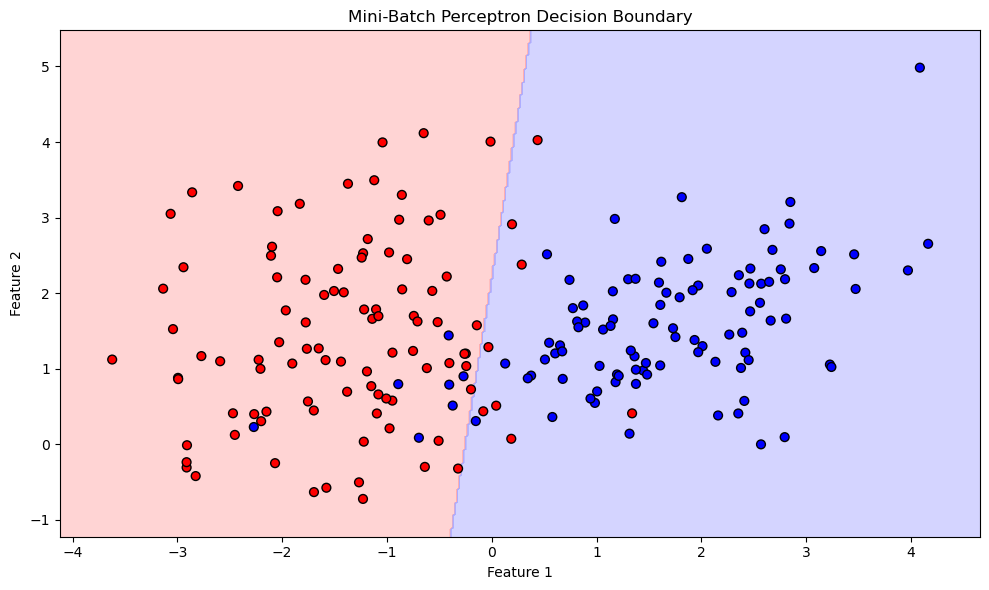

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification


X_train, y_train = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                                       n_informative=2, n_clusters_per_class=1, 
                                       class_sep=1.5, random_state=42)

y_train = np.where(y_train == 0, -1, 1)
clf = Perceptron(learning_rate=0.01, batch_size=16, max_iter=100, verbose=True)
clf.fit(X_train, y_train)

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=40)
plt.title("Mini-Batch Perceptron Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()